# Data Acquisition and Cleaning

Global Happiness Analysis (2019 Data): https://www.kaggle.com/datasets/unsdsn/world-happiness?select=2017.csv

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# UPLOADING THE CSV FILE
from google.colab import files
uploaded = files.upload()  # Prompts to upload a file from your computer

# LOADING THE DATASET
df = pd.read_csv("2019.csv")  # Changed from 'data' to 'df' for consistency

# INITIAL DATA EXPLORATION
print("First 5 rows of the dataset:")
print(df.head())  # Displays the first 5 rows of the data

# Check for missing values
print("\nMissing values check:")
print(df.isnull().sum())

# Rename columns for easier access
df.columns = ['Rank', 'Country', 'Score', 'GDP', 'SocialSupport',
              'Health', 'Freedom', 'Generosity', 'Corruption']

# Verify data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nDescriptive statistics:")
print(df.describe())

Saving 2019.csv to 2019 (1).csv
First 5 rows of the dataset:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0.999                         0.557       0.322   

   Perceptions of corruption  
0                 

# Data Analysis - Objective 1: Happiest and Least Happy Countries
Question 5: Top 5 happiest countries by Happiness Score descending

In [6]:
# Top 5 happiest countries
top5_happiest = df.nlargest(5, 'Score')[['Rank', 'Country', 'Score']]
print("=" * 50)
print("TOP 5 HAPPIEST COUNTRIES (2019)")
print("=" * 50)
print(top5_happiest.to_string(index=False))
print()

# Bottom 5 least happy countries
bottom5_least = df.nsmallest(5, 'Score')[['Rank', 'Country', 'Score']]
print("=" * 50)
print("BOTTOM 5 LEAST HAPPY COUNTRIES (2019)")
print("=" * 50)
print(bottom5_least.to_string(index=False))

TOP 5 HAPPIEST COUNTRIES (2019)
 Rank     Country  Score
    1     Finland  7.769
    2     Denmark  7.600
    3      Norway  7.554
    4     Iceland  7.494
    5 Netherlands  7.488

BOTTOM 5 LEAST HAPPY COUNTRIES (2019)
 Rank                  Country  Score
  156              South Sudan  2.853
  155 Central African Republic  3.083
  154              Afghanistan  3.203
  153                 Tanzania  3.231
  152                   Rwanda  3.334


# Data Analysis - Objective 2: Correlation Analysis

In [8]:
# Calculate correlation with Happiness Score
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Score'].sort_values(ascending=False)

print("=" * 60)
print("CORRELATION WITH HAPPINESS SCORE (Strongest to Weakest)")
print("=" * 60)
for var, corr in correlations.items():
    if var != 'Score' and var != 'Rank':
        print(f"{var:20} : {corr:.4f}")

CORRELATION WITH HAPPINESS SCORE (Strongest to Weakest)
GDP                  : 0.7939
Health               : 0.7799
SocialSupport        : 0.7771
Freedom              : 0.5667
Corruption           : 0.3856
Generosity           : 0.0758


# Data Analysis - Objective 3: Regional Comparison

In [9]:
# Create region categories based on geography
def assign_region(country):
    europe = ['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands', 'Switzerland',
              'Sweden', 'Austria', 'Belgium', 'Germany', 'France', 'Spain', 'Italy',
              'United Kingdom', 'Ireland', 'Luxembourg', 'Malta', 'Czech Republic',
              'Slovakia', 'Poland', 'Hungary', 'Romania', 'Bulgaria', 'Greece',
              'Portugal', 'Croatia', 'Serbia', 'Bosnia', 'Albania', 'North Macedonia',
              'Montenegro', 'Slovenia', 'Estonia', 'Latvia', 'Lithuania', 'Ukraine',
              'Belarus', 'Moldova', 'Russia', 'Cyprus']

    asia = ['China', 'India', 'Japan', 'South Korea', 'Indonesia', 'Pakistan',
            'Bangladesh', 'Philippines', 'Vietnam', 'Thailand', 'Malaysia', 'Nepal',
            'Sri Lanka', 'Myanmar', 'Mongolia', 'Kazakhstan', 'Uzbekistan', 'Tajikistan',
            'Kyrgyzstan', 'Turkmenistan', 'Laos', 'Cambodia', 'Afghanistan', 'Iran',
            'Iraq', 'Saudi Arabia', 'United Arab Emirates', 'Qatar', 'Kuwait', 'Bahrain',
            'Jordan', 'Lebanon', 'Israel', 'Palestinian Territories', 'Syria', 'Yemen']

    africa = ['South Africa', 'Nigeria', 'Egypt', 'Ethiopia', 'Kenya', 'Tanzania',
              'Uganda', 'Algeria', 'Morocco', 'Sudan', 'Ghana', 'Angola', 'Mozambique',
              'Madagascar', 'Cameroon', 'Niger', 'Burkina Faso', 'Mali', 'Malawi',
              'Zambia', 'Somalia', 'Chad', 'South Sudan', 'Rwanda', 'Burundi',
              'Benin', 'Tunisia', 'Libya', 'Liberia', 'Mauritania', 'Botswana',
              'Namibia', 'Gabon', 'Lesotho', 'Zimbabwe', 'Congo', 'Swaziland',
              'Mauritius', 'Sierra Leone', 'Togo', 'Comoros', 'Guinea', 'Gambia',
              'Senegal', 'Ivory Coast']

    americas = ['United States', 'Canada', 'Mexico', 'Brazil', 'Argentina', 'Chile',
                'Colombia', 'Peru', 'Venezuela', 'Ecuador', 'Bolivia', 'Paraguay',
                'Uruguay', 'Guyana', 'Suriname', 'French Guiana', 'Costa Rica',
                'Guatemala', 'Honduras', 'Nicaragua', 'El Salvador', 'Panama',
                'Cuba', 'Haiti', 'Dominican Republic', 'Jamaica', 'Trinidad']

    oceania = ['Australia', 'New Zealand']

    if country in europe: return 'Europe'
    elif country in asia: return 'Asia'
    elif country in africa: return 'Africa'
    elif country in americas: return 'Americas'
    elif country in oceania: return 'Oceania'
    else: return 'Other'

df['Region'] = df['Country'].apply(assign_region)

# Calculate regional averages
regional_avg = df.groupby('Region')['Score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("=" * 60)
print("REGIONAL AVERAGE HAPPINESS SCORES")
print("=" * 60)
print(regional_avg.round(3))

REGIONAL AVERAGE HAPPINESS SCORES
           mean  count
Region                
Oceania   7.268      2
Europe    6.295     39
Americas  6.046     22
Other     5.239     15
Asia      5.211     36
Africa    4.387     42


# Data Analysis - Objective 4: Visualizations

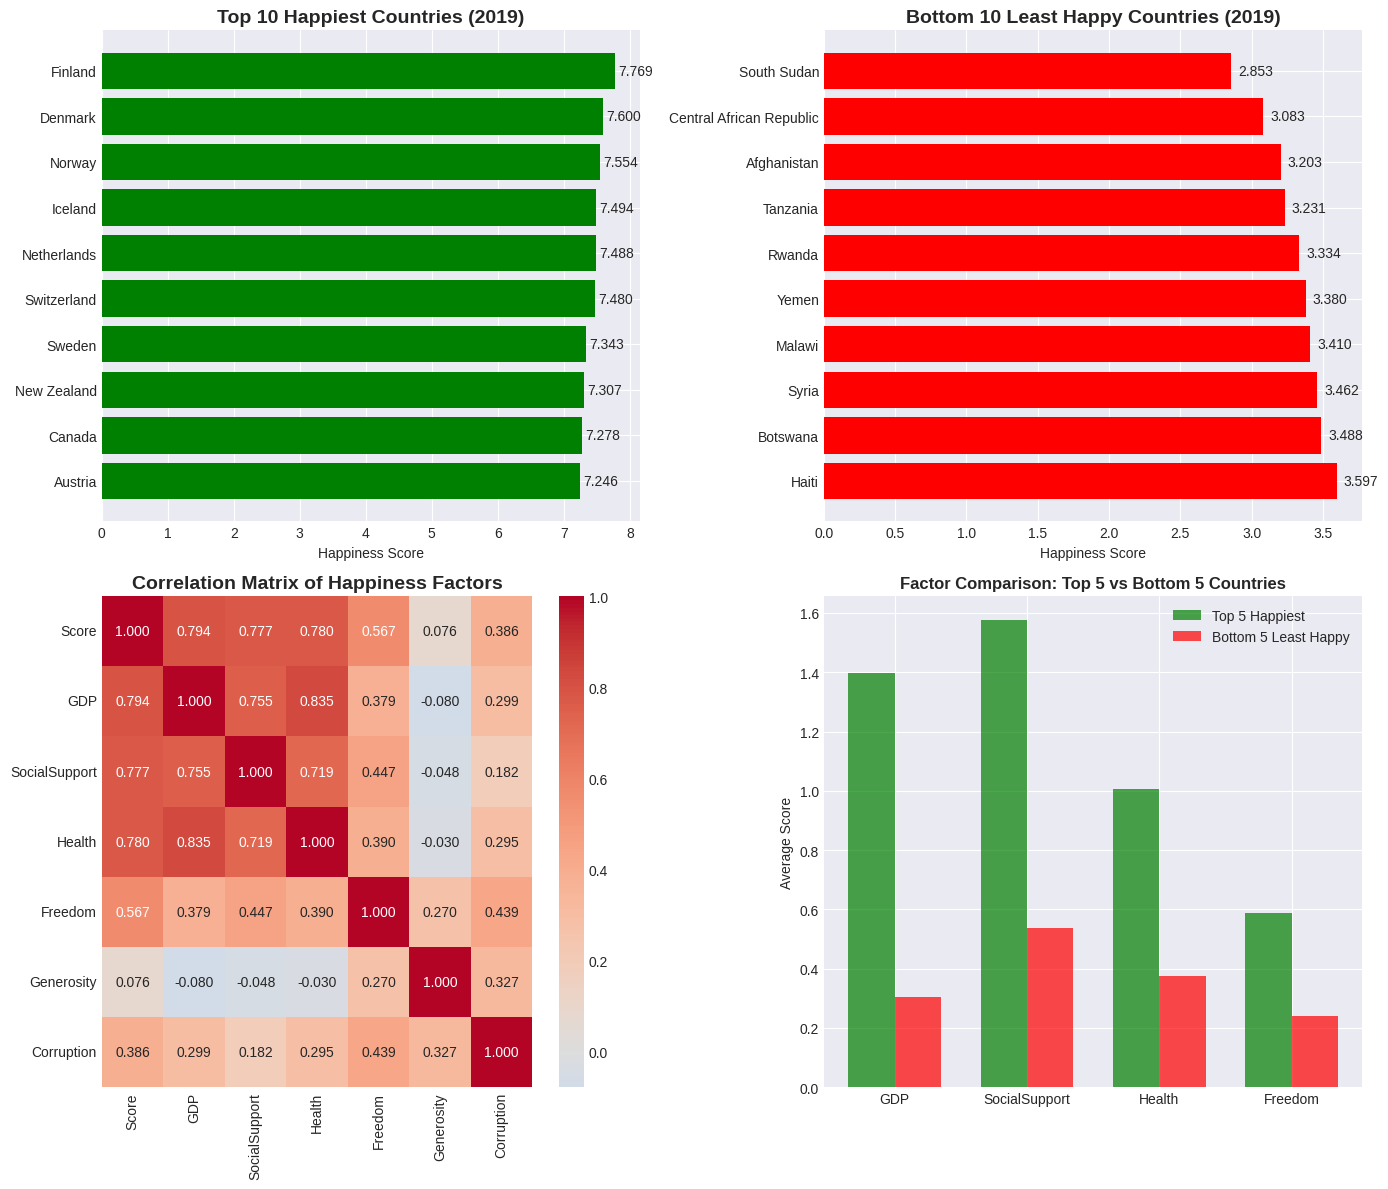

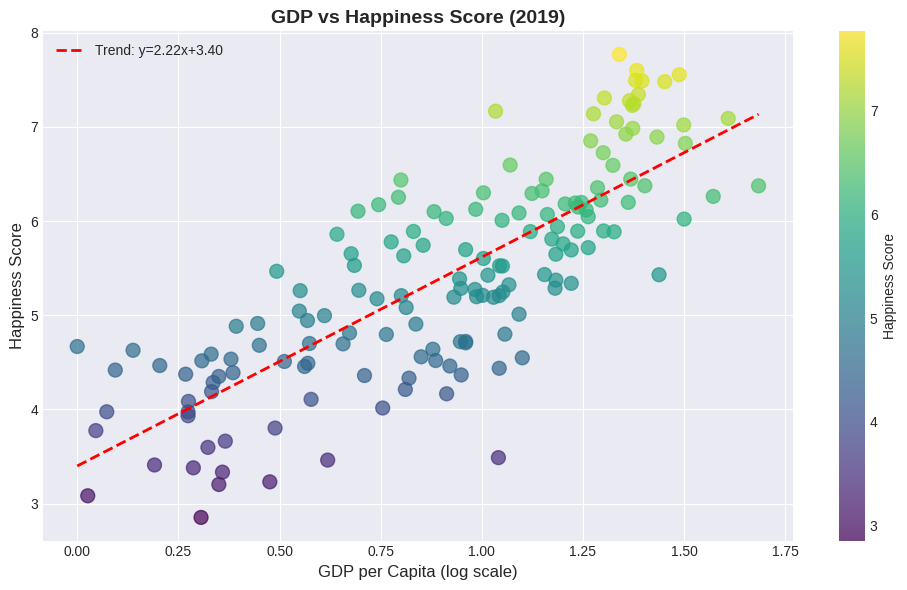

In [10]:
# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# FIGURE 1: Top 10 Happiest Countries
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Top 10 Happiest Countries
top10 = df.nlargest(10, 'Score')
axes[0, 0].barh(top10['Country'], top10['Score'], color='green')
axes[0, 0].set_xlabel('Happiness Score')
axes[0, 0].set_title('Top 10 Happiest Countries (2019)', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()
for i, v in enumerate(top10['Score']):
    axes[0, 0].text(v + 0.05, i, f'{v:.3f}', va='center')

# Plot 2: Bottom 10 Least Happy Countries
bottom10 = df.nsmallest(10, 'Score')
axes[0, 1].barh(bottom10['Country'], bottom10['Score'], color='red')
axes[0, 1].set_xlabel('Happiness Score')
axes[0, 1].set_title('Bottom 10 Least Happy Countries (2019)', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()
for i, v in enumerate(bottom10['Score']):
    axes[0, 1].text(v + 0.05, i, f'{v:.3f}', va='center')

# Plot 3: Correlation Heatmap
corr_matrix = df[['Score', 'GDP', 'SocialSupport', 'Health', 'Freedom', 'Generosity', 'Corruption']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0], fmt='.3f')
axes[1, 0].set_title('Correlation Matrix of Happiness Factors', fontsize=14, fontweight='bold')

# Plot 4: Factor Comparison - Top 5 vs Bottom 5
factors = ['GDP', 'SocialSupport', 'Health', 'Freedom']
top5_avg = df.nlargest(5, 'Score')[factors].mean()
bottom5_avg = df.nsmallest(5, 'Score')[factors].mean()

x = range(len(factors))
width = 0.35
axes[1, 1].bar([i - width/2 for i in x], top5_avg, width, label='Top 5 Happiest', color='green', alpha=0.7)
axes[1, 1].bar([i + width/2 for i in x], bottom5_avg, width, label='Bottom 5 Least Happy', color='red', alpha=0.7)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(factors)
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].set_title('Factor Comparison: Top 5 vs Bottom 5 Countries', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('happiness_analysis_figures.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURE 5: Scatter Plot - GDP vs Happiness
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['GDP'], df['Score'], c=df['Score'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='Happiness Score')
plt.xlabel('GDP per Capita (log scale)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('GDP vs Happiness Score (2019)', fontsize=14, fontweight='bold')

# Add trend line
z = np.polyfit(df['GDP'], df['Score'], 1)
p = np.poly1d(z)
plt.plot(df['GDP'].sort_values(), p(df['GDP'].sort_values()), "r--", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('gdp_happiness_scatter.png', dpi=300)
plt.show()